In [45]:
import os
import json
import shutil
from collections import Counter

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

In [46]:
def parse_digitstruct_mat(mat_path):
    f = h5py.File(mat_path, "r")
    ds = f["digitStruct"]
    names_ref = ds["name"]
    bbox_ref = ds["bbox"]
    n = names_ref.shape[0]

    def get_name(idx):
        ref = names_ref[idx][0]
        return "".join(chr(c) for c in f[ref][()].flatten())

    def get_attr(bbox_obj, attr_name):
        attr = bbox_obj[attr_name]
        if attr.shape[0] == 1:
            return [float(attr[0][0])]
        return [float(f[attr[i][0]][()].flatten()[0]) for i in range(attr.shape[0])]

    annotations = []
    for i in range(n):
        bbox_obj = f[bbox_ref[i][0]]
        labels = get_attr(bbox_obj, "label")
        lefts = get_attr(bbox_obj, "left")
        tops = get_attr(bbox_obj, "top")
        widths = get_attr(bbox_obj, "width")
        heights = get_attr(bbox_obj, "height")

        boxes = []
        for lb, l, t, w, h in zip(labels, lefts, tops, widths, heights):
            cls = int(lb) % 10
            boxes.append({"label": cls, "left": l, "top": t, "width": w, "height": h})
        annotations.append({"filename": get_name(i), "boxes": boxes})

    f.close()
    return annotations


train_ann = parse_digitstruct_mat("data/svhn/train/digitStruct.mat")
test_ann = parse_digitstruct_mat("data/svhn/test/digitStruct.mat")

print(f"Train: {len(train_ann)}, Test: {len(test_ann)}")
print(f"Пример: {train_ann[0]}")

Train: 33402, Test: 13068
Пример: {'filename': '1.png', 'boxes': [{'label': 1, 'left': 246.0, 'top': 77.0, 'width': 81.0, 'height': 219.0}, {'label': 9, 'left': 323.0, 'top': 81.0, 'width': 96.0, 'height': 219.0}]}


In [47]:
def convert_to_yolo(annotations, src_img_dir, dst_dir):
    img_dir = os.path.join(dst_dir, "images")
    lbl_dir = os.path.join(dst_dir, "labels")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    skipped = 0
    for ann in annotations:
        fname = ann["filename"]
        src_path = os.path.join(src_img_dir, fname)
        if not os.path.exists(src_path):
            skipped += 1
            continue

        img = Image.open(src_path)
        img_w, img_h = img.size

        dst_img = os.path.join(img_dir, fname)
        if not os.path.exists(dst_img):
            shutil.copy2(src_path, dst_img)

        stem = os.path.splitext(fname)[0]
        lbl_path = os.path.join(lbl_dir, f"{stem}.txt")
        lines = []
        for box in ann["boxes"]:
            cx = max(0, min(1, (box["left"] + box["width"] / 2) / img_w))
            cy = max(0, min(1, (box["top"] + box["height"] / 2) / img_h))
            bw = max(0, min(1, box["width"] / img_w))
            bh = max(0, min(1, box["height"] / img_h))
            lines.append(f"{box['label']} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

        with open(lbl_path, "w") as f:
            f.write("\n".join(lines))

    print(f"OK: {len(annotations) - skipped}, skipped: {skipped}")


convert_to_yolo(train_ann, "data/svhn/train", "data/svhn_yolo/train")
convert_to_yolo(test_ann, "data/svhn/test", "data/svhn_yolo/val")

print(f"Train images: {len(os.listdir('data/svhn_yolo/train/images'))}")
print(f"Val images:   {len(os.listdir('data/svhn_yolo/val/images'))}")

OK: 17826, skipped: 15576
OK: 8875, skipped: 4193
Train images: 17826
Val images:   8875


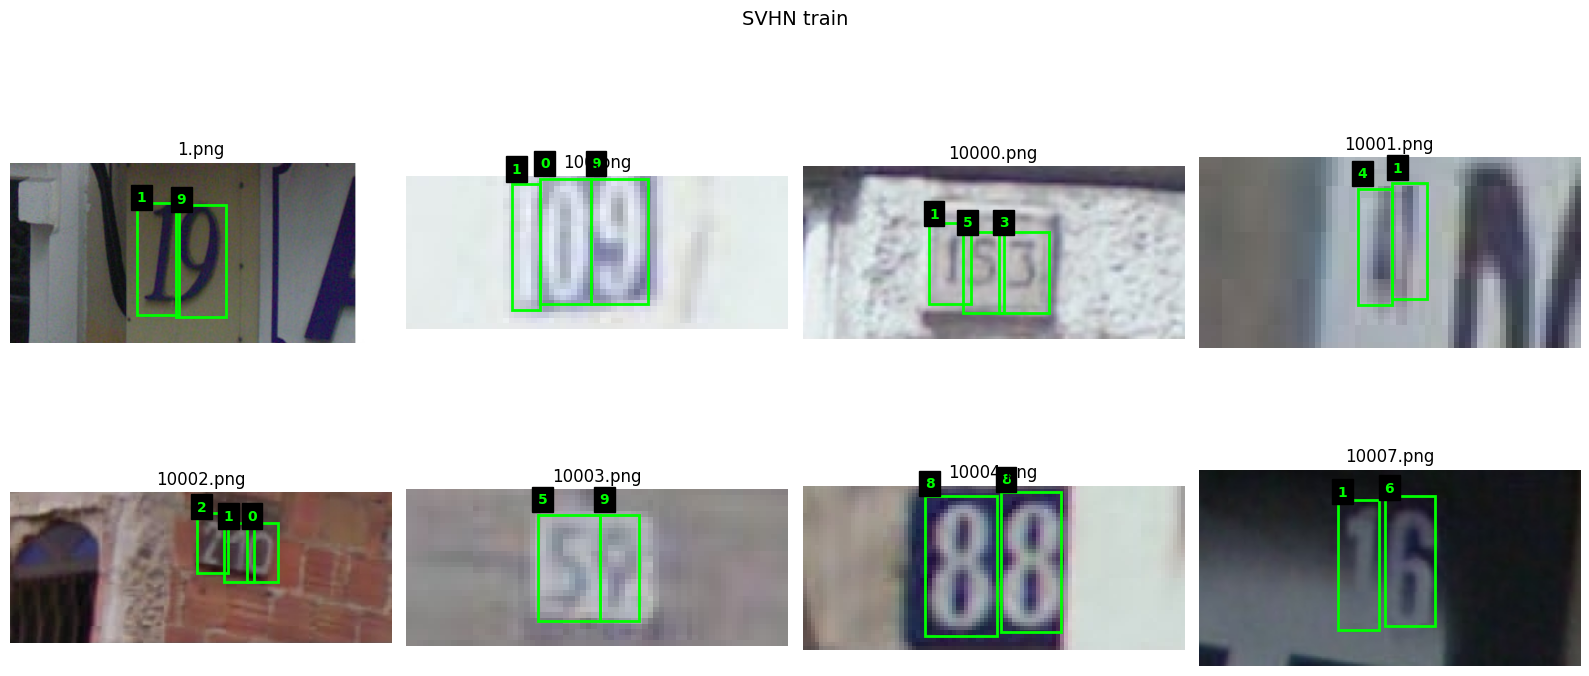

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

img_dir = "data/svhn_yolo/train/images"
lbl_dir = "data/svhn_yolo/train/labels"
img_files = sorted(os.listdir(img_dir))[:8]

for ax, fname in zip(axes.flat, img_files):
    img = Image.open(os.path.join(img_dir, fname))
    img_w, img_h = img.size
    ax.imshow(img)

    lbl_path = os.path.join(lbl_dir, os.path.splitext(fname)[0] + ".txt")
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                cx, cy, bw, bh = [float(x) for x in parts[1:]]
                x1 = (cx - bw / 2) * img_w
                y1 = (cy - bh / 2) * img_h
                rect = plt.Rectangle((x1, y1), bw * img_w, bh * img_h,
                                     linewidth=2, edgecolor="lime", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 2, str(cls), color="lime", fontsize=10,
                        fontweight="bold", backgroundcolor="black")
    ax.set_title(fname)
    ax.axis("off")

plt.suptitle("SVHN train", fontsize=14)
plt.tight_layout()
plt.show()

Всего bbox: 39068
  0: 2630 (6.7%)
  1: 7395 (18.9%)
  2: 5640 (14.4%)
  3: 4582 (11.7%)
  4: 3899 (10.0%)
  5: 3639 (9.3%)
  6: 3078 (7.9%)
  7: 3014 (7.7%)
  8: 2678 (6.9%)
  9: 2513 (6.4%)


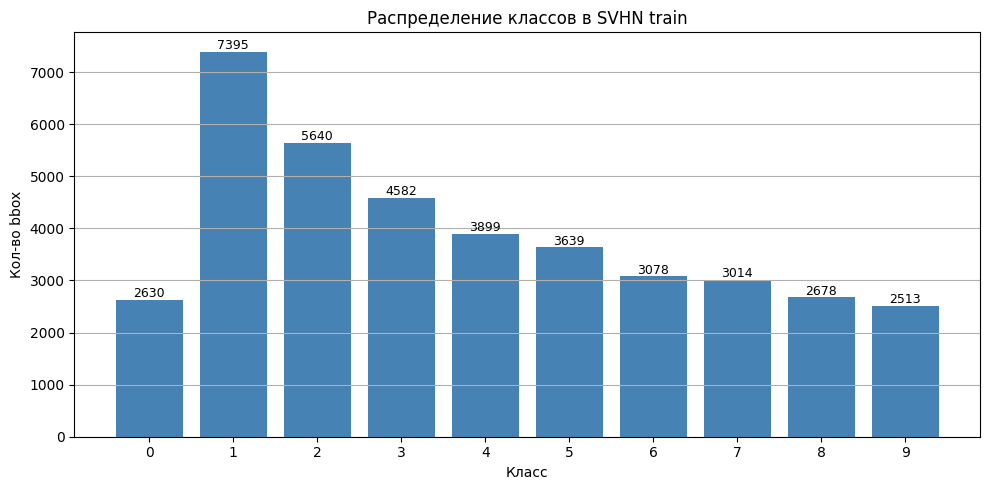

In [49]:
train_lbl_dir = "data/svhn_yolo/train/labels"
class_counter = Counter()

for lbl_file in os.listdir(train_lbl_dir):
    if not lbl_file.endswith(".txt"):
        continue
    with open(os.path.join(train_lbl_dir, lbl_file)) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counter[int(parts[0])] += 1

total_boxes = sum(class_counter.values())
print(f"Всего bbox: {total_boxes}")
for cls in sorted(class_counter.keys()):
    print(f"  {cls}: {class_counter[cls]} ({class_counter[cls]/total_boxes*100:.1f}%)")

plt.figure(figsize=(10, 5))
classes_sorted = sorted(class_counter.keys())
counts = [class_counter[c] for c in classes_sorted]
bars = plt.bar([str(c) for c in classes_sorted], counts, color="steelblue")
for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             str(cnt), ha="center", fontsize=9)
plt.xlabel("Класс")
plt.ylabel("Кол-во bbox")
plt.title("Распределение классов в SVHN train")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(
    data="svhn.yaml",
    epochs=5,
    imgsz=320,
    batch=128,
    patience=3,
    name="svhn_det",
    exist_ok=True,
    device="cpu",
    pretrained=True,
    optimizer="auto",
    seed=0,
    deterministic=True,
    cache="ram",
    workers=8,
    amp=True,
    cos_lr=True,
)

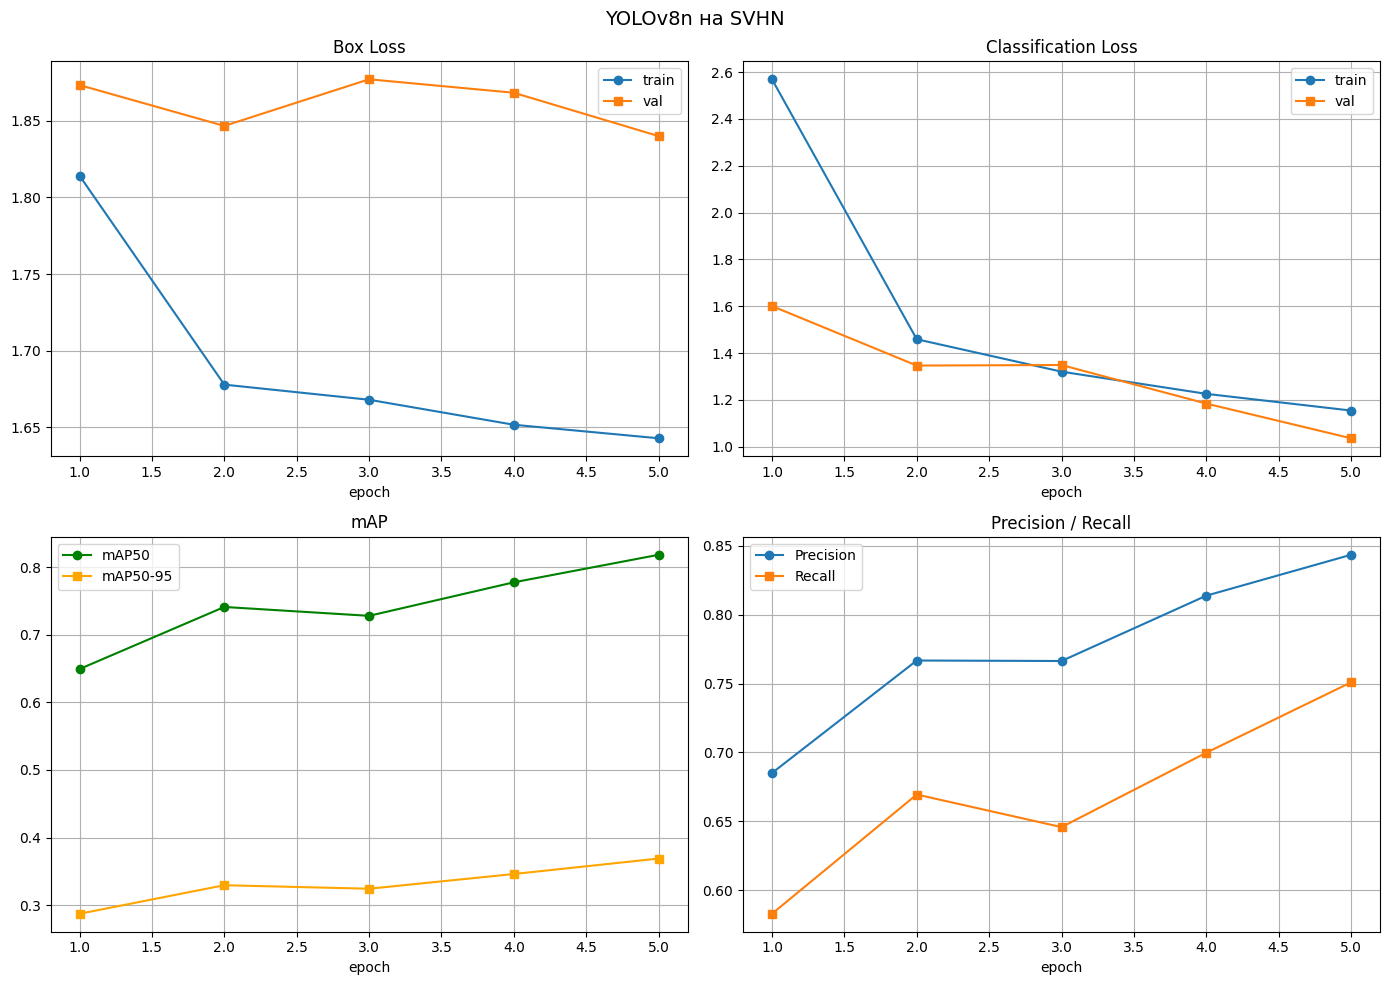

Лучшая эпоха: 5
  mAP50     = 0.8182
  mAP50-95  = 0.3689
  Precision = 0.8435
  Recall    = 0.7509


In [51]:
csv_path = "runs/detect/svhn_det/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df["epoch"], df["train/box_loss"], label="train", marker="o")
axes[0, 0].plot(df["epoch"], df["val/box_loss"], label="val", marker="s")
axes[0, 0].set_title("Box Loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(df["epoch"], df["train/cls_loss"], label="train", marker="o")
axes[0, 1].plot(df["epoch"], df["val/cls_loss"], label="val", marker="s")
axes[0, 1].set_title("Classification Loss")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50", marker="o", color="green")
axes[1, 0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95", marker="s", color="orange")
axes[1, 0].set_title("mAP")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(df["epoch"], df["metrics/precision(B)"], label="Precision", marker="o")
axes[1, 1].plot(df["epoch"], df["metrics/recall(B)"], label="Recall", marker="s")
axes[1, 1].set_title("Precision / Recall")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle("YOLOv8n на SVHN", fontsize=14)
plt.tight_layout()
plt.show()

best_idx = df["metrics/mAP50(B)"].idxmax()
print(f"Лучшая эпоха: {df.loc[best_idx, 'epoch']:.0f}")
print(f"  mAP50     = {df.loc[best_idx, 'metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95  = {df.loc[best_idx, 'metrics/mAP50-95(B)']:.4f}")
print(f"  Precision = {df.loc[best_idx, 'metrics/precision(B)']:.4f}")
print(f"  Recall    = {df.loc[best_idx, 'metrics/recall(B)']:.4f}")

In [73]:
best_model = YOLO("runs/detect/svhn_det/weights/best.pt")

val_results = best_model.val(
    data="svhn.yaml",
    imgsz=320,
    batch=128,
    device="cpu",
    plots=True,
)

print("=== Метрики на тестовой части SVHN ===")
print(f"IoU порог:  0.50")
print(f"mAP50:      {val_results.box.map50:.4f}")
print(f"mAP50-95:   {val_results.box.map:.4f}")
print(f"Precision:  {val_results.box.mp:.4f}")
print(f"Recall:     {val_results.box.mr:.4f}")

print(f"\nmAP50 = {val_results.box.map50:.4f} {'>= 0.6' if val_results.box.map50 >= 0.6 else '< 0.6'}")

Ultralytics 8.4.33 🚀 Python-3.9.6 torch-2.2.2 CPU (Apple M1 Pro)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 54.6±32.1 MB/s, size: 16.5 KB)
val: Scanning /Users/kirilllesniak/itmo/ml/lab-5/data/svhn_yolo/val/labels.cache... 8875 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8875/8875 232.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 2/70 5.7s/it 5.3s<6:30


KeyboardInterrupt: 

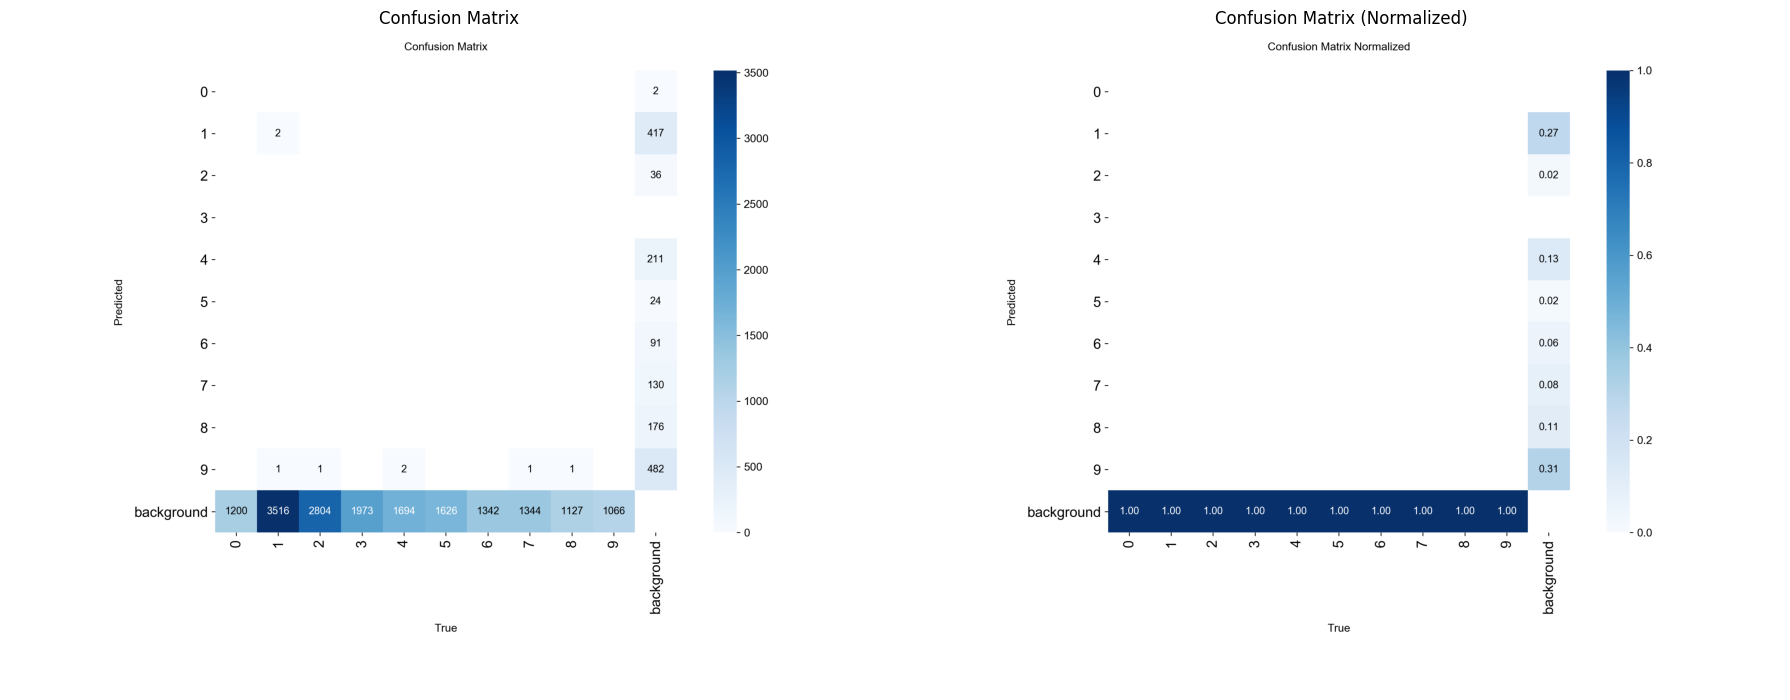

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(Image.open("runs/detect/val2/confusion_matrix.png"))
axes[0].set_title("Confusion Matrix")
axes[0].axis("off")

axes[1].imshow(Image.open("runs/detect/val2/confusion_matrix_normalized.png"))
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

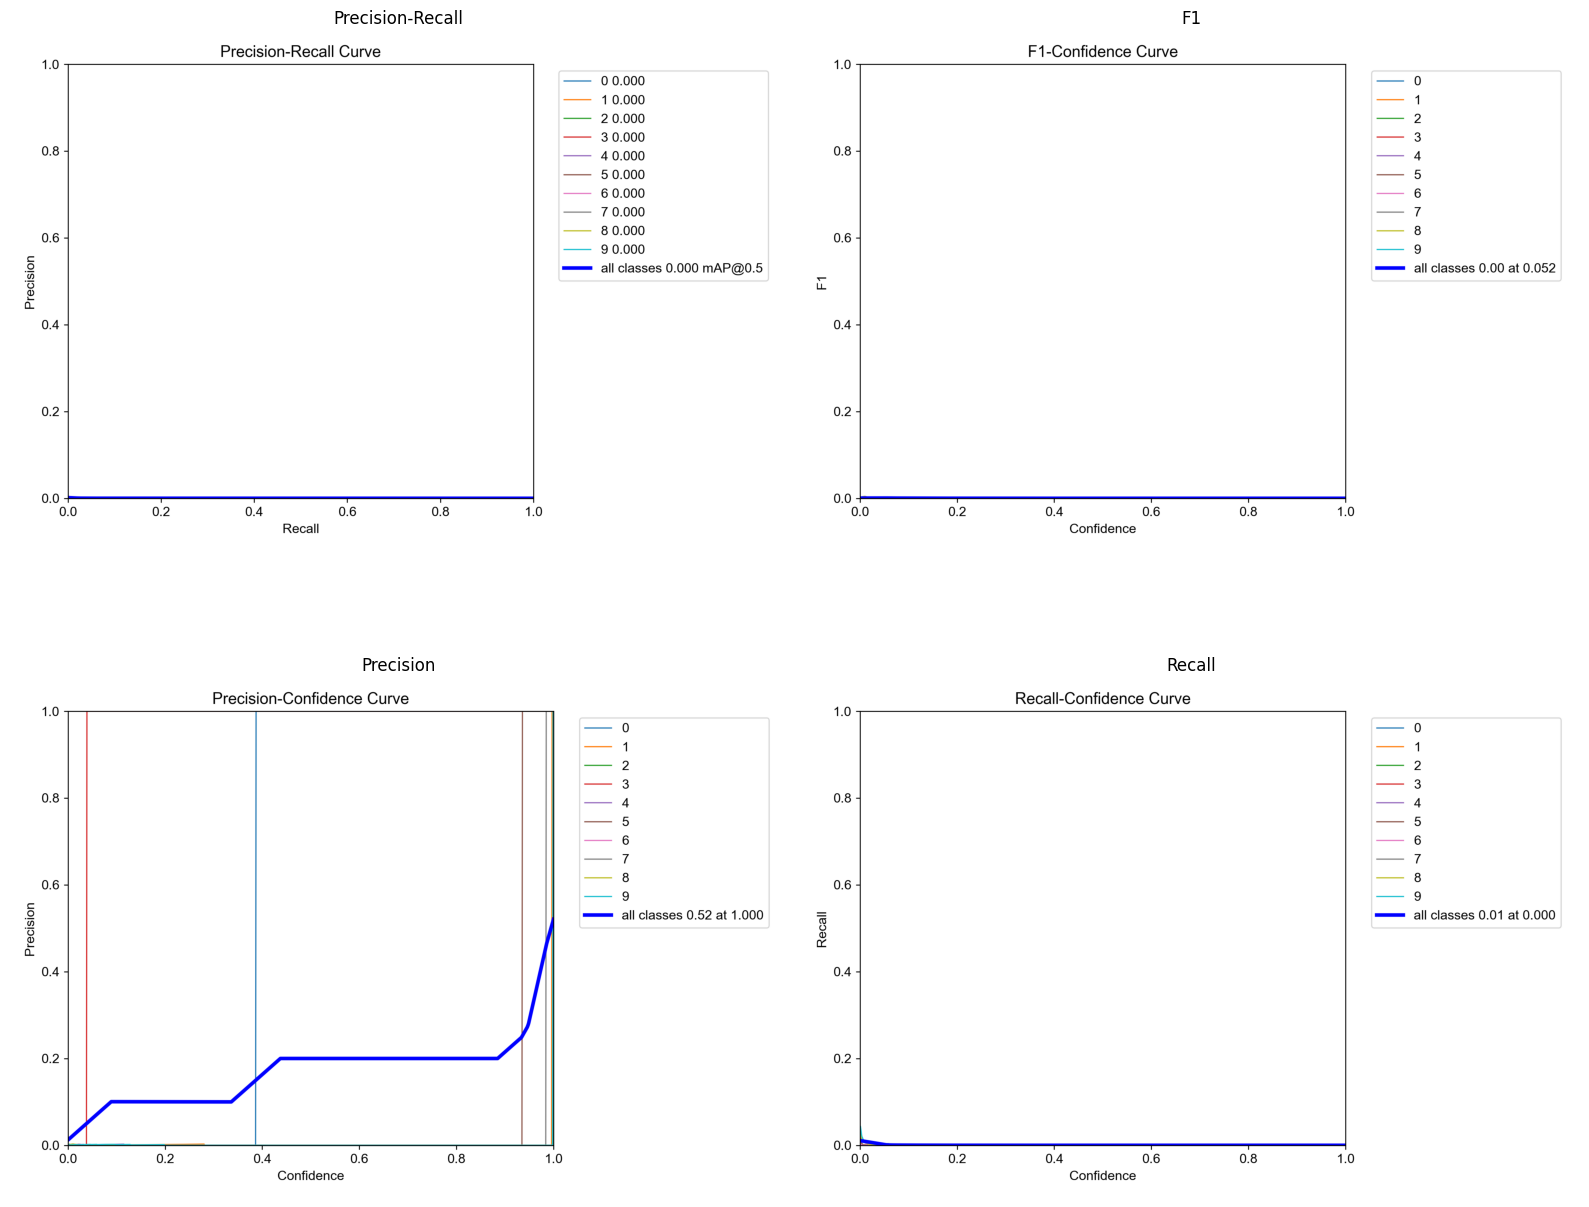

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (path, title) in zip(axes.flat, [
    ("runs/detect/val2/BoxPR_curve.png", "Precision-Recall"),
    ("runs/detect/val2/BoxF1_curve.png", "F1"),
    ("runs/detect/val2/BoxP_curve.png", "Precision"),
    ("runs/detect/val2/BoxR_curve.png", "Recall"),
]):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

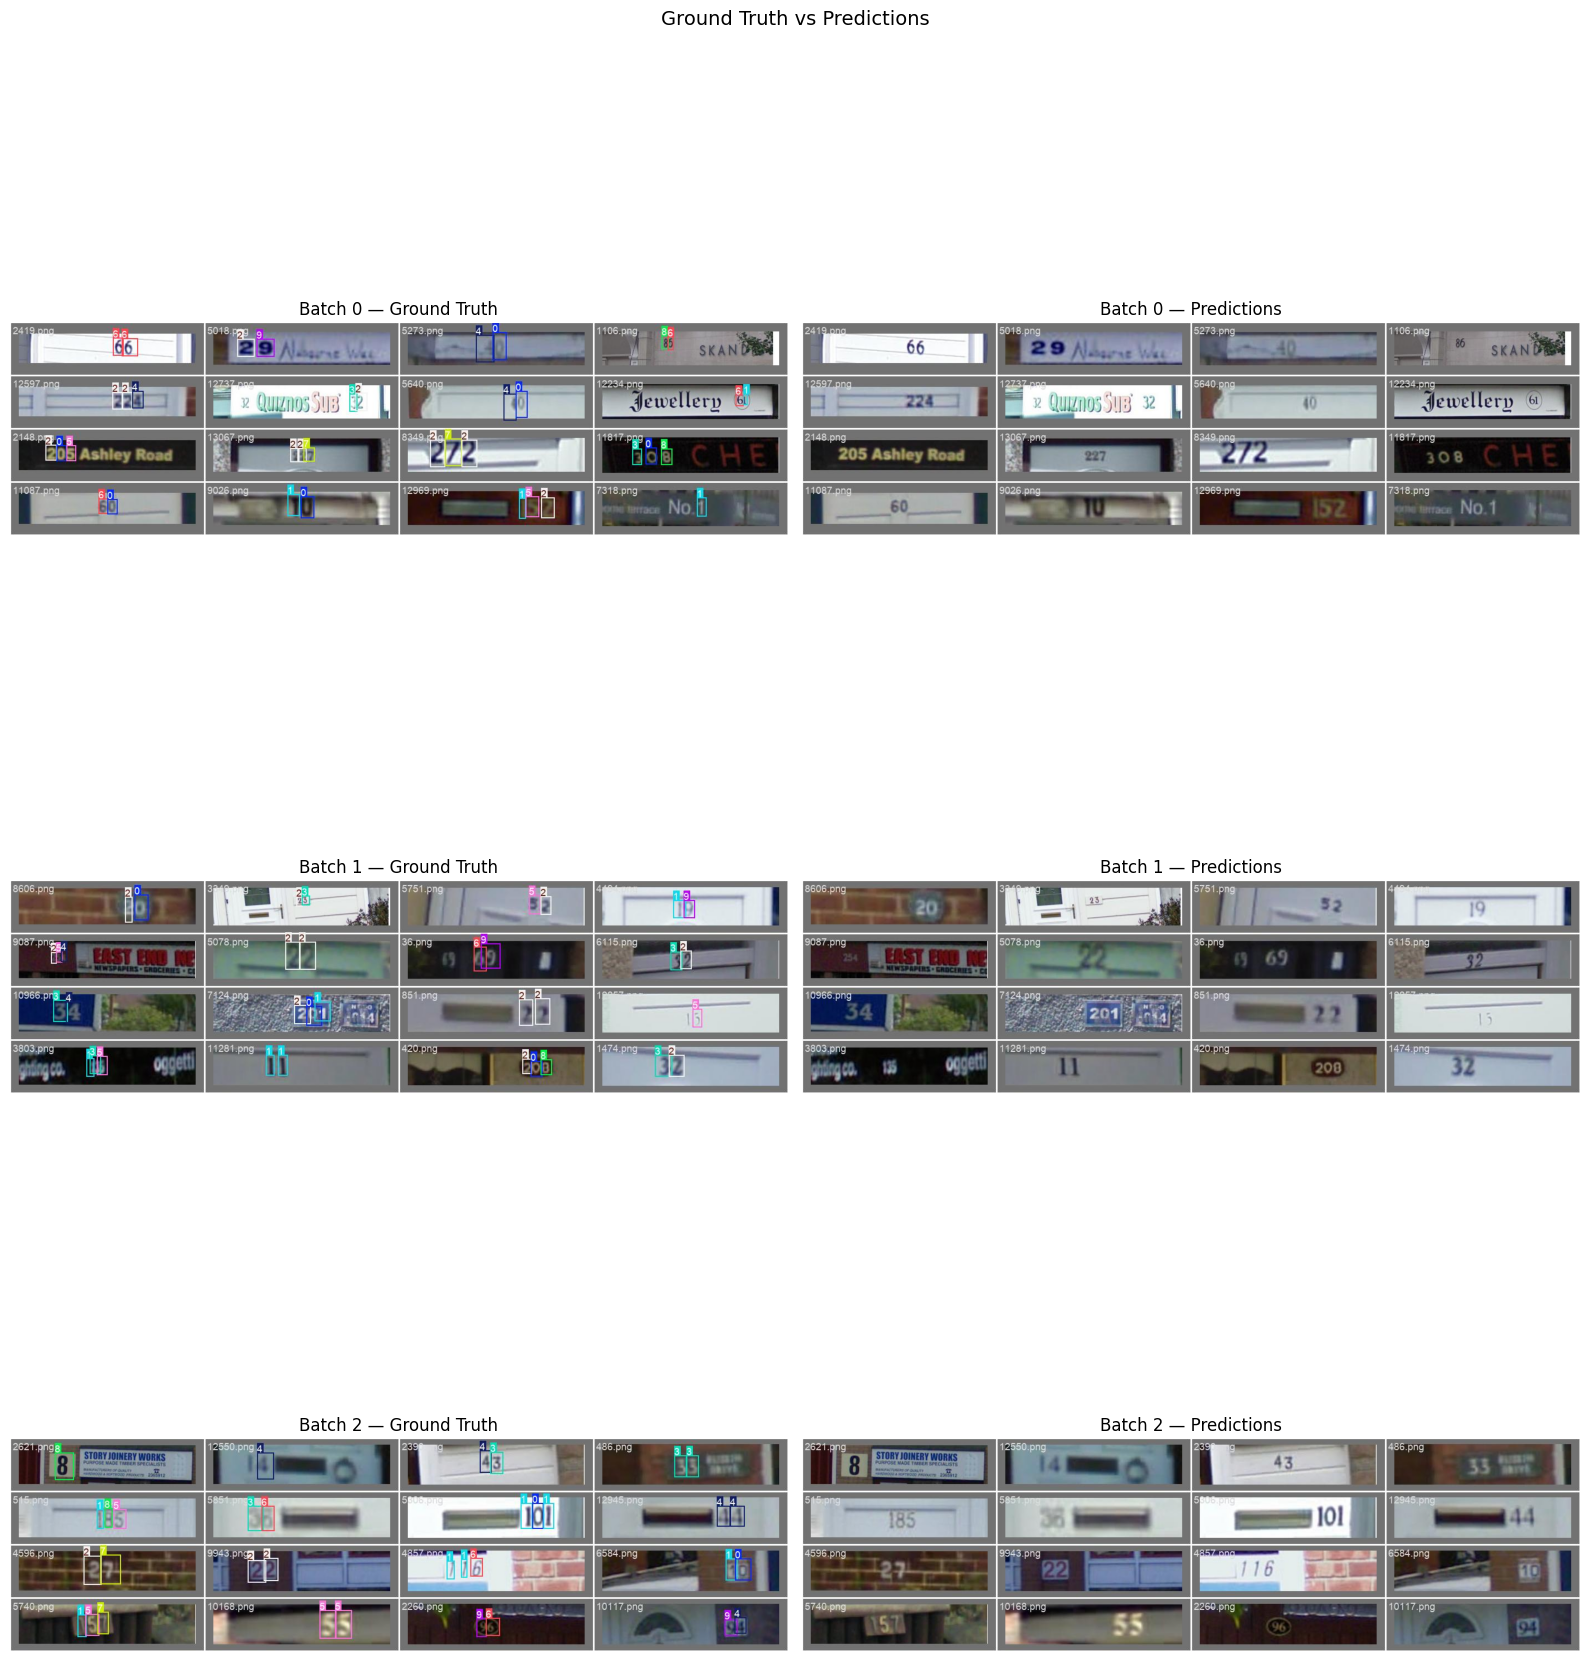

In [76]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

for i in range(3):
    axes[i, 0].imshow(Image.open(f"runs/detect/val2/val_batch{i}_labels.jpg"))
    axes[i, 0].set_title(f"Batch {i} — Ground Truth")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(Image.open(f"runs/detect/val2/val_batch{i}_pred.jpg"))
    axes[i, 1].set_title(f"Batch {i} — Predictions")
    axes[i, 1].axis("off")

plt.suptitle("Ground Truth vs Predictions", fontsize=14)
plt.tight_layout()
plt.show()

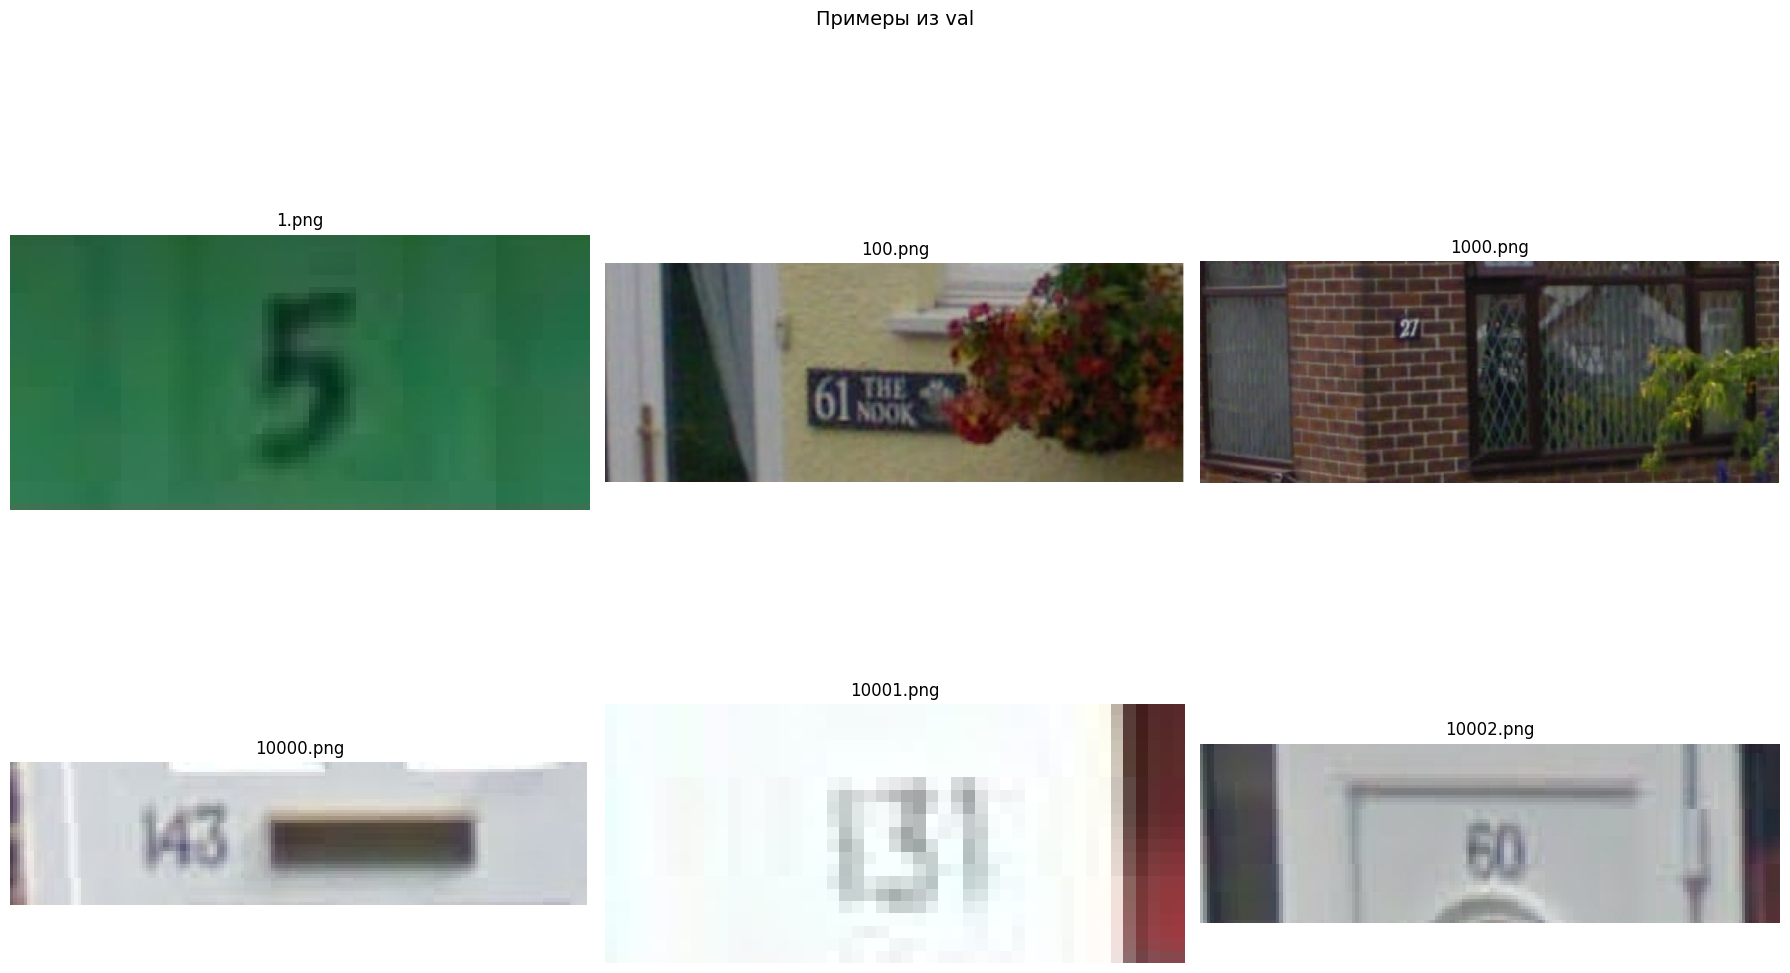

In [77]:
val_img_dir = "data/svhn_yolo/val/images"
sample_imgs = sorted(os.listdir(val_img_dir))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, fname in zip(axes.flat, sample_imgs):
    img = Image.open(os.path.join(val_img_dir, fname))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis("off")

plt.suptitle("Примеры из val", fontsize=14)
plt.tight_layout()
plt.show()

Фотографий: 2


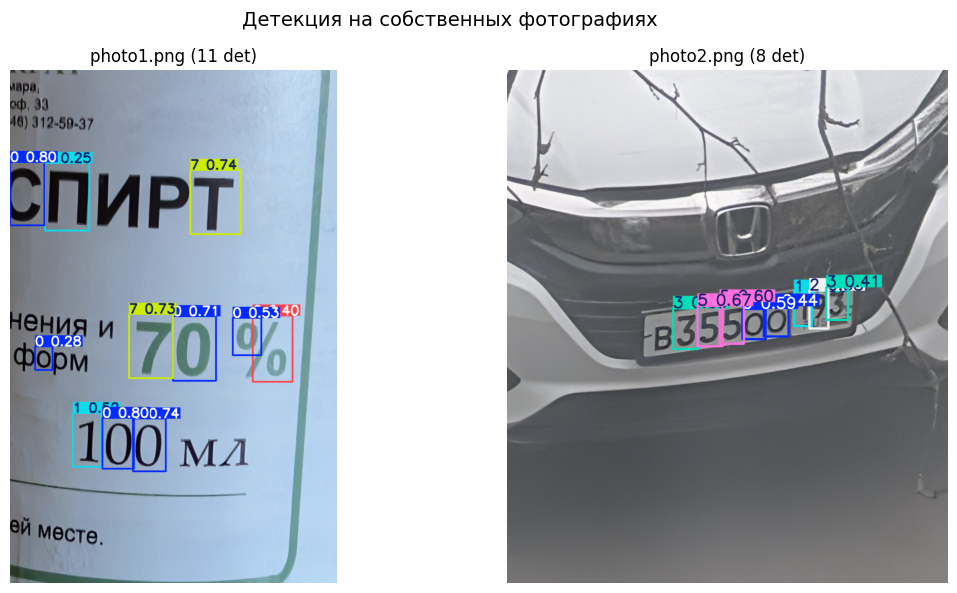

In [78]:
my_photos_dir = "data/my_photos"
os.makedirs(my_photos_dir, exist_ok=True)
my_photos = [f for f in sorted(os.listdir(my_photos_dir)) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"Фотографий: {len(my_photos)}")

if my_photos:
    best_model = YOLO("runs/detect/svhn_det/weights/best.pt")
    cols = min(3, len(my_photos))
    rows = (len(my_photos) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = np.array(axes).flat

    for ax, fname in zip(axes, my_photos):
        img_path = os.path.join(my_photos_dir, fname)
        preds = best_model.predict(img_path, imgsz=640, conf=0.25, verbose=False)
        annotated = preds[0].plot()
        ax.imshow(annotated[:, :, ::-1])
        n_det = len(preds[0].boxes)
        ax.set_title(f"{fname} ({n_det} det)")
        ax.axis("off")

    for ax in list(axes)[len(my_photos):]:
        ax.axis("off")

    plt.suptitle("Детекция на собственных фотографиях", fontsize=14)
    plt.tight_layout()
    plt.show()

In [79]:
csv_path = "runs/detect/svhn_det/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

best_idx = df["metrics/mAP50(B)"].idxmax()
best_row = df.iloc[best_idx]

output = {
    "task": "object_detection",
    "dataset": "SVHN (Street View House Numbers)",
    "model": "YOLOv8n (pretrained COCO)",
    "num_classes": 10,
    "classes": [str(i) for i in range(10)],
    "train_size": len(os.listdir("data/svhn_yolo/train/images")),
    "val_size": len(os.listdir("data/svhn_yolo/val/images")),
    "hyperparameters": {
        "imgsz": 320,
        "batch": 64,
        "epochs": 5,
        "patience": 3,
        "optimizer": "auto",
        "lr0": 0.01,
        "device": "cpu",
    },
    "best_epoch": int(best_row["epoch"]),
    "metrics": {
        "mAP50": round(float(best_row["metrics/mAP50(B)"]), 4),
        "mAP50_95": round(float(best_row["metrics/mAP50-95(B)"]), 4),
        "precision": round(float(best_row["metrics/precision(B)"]), 4),
        "recall": round(float(best_row["metrics/recall(B)"]), 4),
    },
}

with open("results.json", "w") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(json.dumps(output, indent=2, ensure_ascii=False))

{
  "task": "object_detection",
  "dataset": "SVHN (Street View House Numbers)",
  "model": "YOLOv8n (pretrained COCO)",
  "num_classes": 10,
  "classes": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
  ],
  "train_size": 17826,
  "val_size": 8875,
  "hyperparameters": {
    "imgsz": 320,
    "batch": 64,
    "epochs": 5,
    "patience": 3,
    "optimizer": "auto",
    "lr0": 0.01,
    "device": "cpu"
  },
  "best_epoch": 5,
  "metrics": {
    "mAP50": 0.8174,
    "mAP50_95": 0.3749,
    "precision": 0.8427,
    "recall": 0.7474
  }
}
